# Line and bar chart: Death rate from indoor air pollution (Thailand, Vietnam, Indonesia, Cambodia, Myanmar, Laos)

In this notebook we recreate an Our World in Data (OWID)-style line and bar chart showing the age-standardized death rate from indoor air pollution for six Southeast Asian countries. This workshop snapshot includes values for **1990** and **2021**.

Goals:
- Practice loading a CSV snapshot.
- Reshape snapshot data into tidy (long) format.
- Add ISO country codes for plotting and joins.
- Create a multi-line chart with endpoint labels and a bar chart for a single year.
- Check that the data cover the expected countries and years.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib style settings (OWID-inspired)
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
# Load indoor air pollution snapshot from notebooks/data/

data_path = "data/indoor_pollution.csv"
df = pd.read_csv(data_path)
df.head()


,Country or region,1990,2021,1990–2023,Absolute Change,Relative Change
0,Cambodia,228.2,127.5,NaN,-100.7,-44%
1,Indonesia,138.0,30.0,NaN,-108.0,-78%
2,Laos,307.6,202.5,NaN,-105.1,-34%
3,Myanmar,341.9,207.9,NaN,-134.0,-39%
4,Thailand,95.4,4.6,NaN,-90.9,-95%


In [3]:
# Inspect columns and basic info (tidy data check)

print(df.columns)
print()
print(df.info())


Index(['Country or region', '1990', '2021', '1990–2023', 'Absolute Change',
       'Relative Change'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country or region  6 non-null      object 
 1   1990               6 non-null      float64
 2   2021               6 non-null      float64
 3   1990–2023          0 non-null      float64
 4   Absolute Change    6 non-null      float64
 5   Relative Change    6 non-null      object 
dtypes: float64(4), object(2)
memory usage: 416.0+ bytes
None


In [4]:
# Reshape the snapshot to tidy long format and add ISO country codes

country_codes = ["KHM", "IDN", "LAO", "MMR", "THA", "VNM"]

country_to_code = {
    "Cambodia": "KHM",
    "Indonesia": "IDN",
    "Laos": "LAO",
    "Myanmar": "MMR",
    "Thailand": "THA",
    "Vietnam": "VNM",
}

# Year columns in the snapshot (e.g. 1990 and 2021)
year_cols = [c for c in df.columns if str(c).isdigit()]

df_long = df.melt(
    id_vars=["Country or region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="death_rate",
)

df_long["Year"] = df_long["Year"].astype(int)

# Convert to float if stored as string
df_long["death_rate"] = df_long["death_rate"].astype(float)

df_long = df_long.rename(columns={"Country or region": "Entity"})
df_long["Code"] = df_long["Entity"].map(country_to_code)

# Filter to expected countries/years
start_year = 1990
end_year = 2021

df_sel = df_long[df_long["Code"].isin(country_codes)].copy()
df_sel = df_sel[(df_sel["Year"] >= start_year) & (df_sel["Year"] <= end_year)]

# Simple assertions to verify coverage
assert set(df_sel["Code"].unique()) == set(country_codes), "Unexpected country codes in filtered data"
assert df_sel["Year"].min() == start_year, "Earliest year is not 1990"
assert df_sel["Year"].max() == end_year, "Latest year is not 2021"

df_sel.head()


,Entity,Year,death_rate,Code
0,Cambodia,1990,228.2,KHM
1,Indonesia,1990,138.0,IDN
2,Laos,1990,307.6,LAO
3,Myanmar,1990,341.9,MMR
4,Thailand,1990,95.4,THA


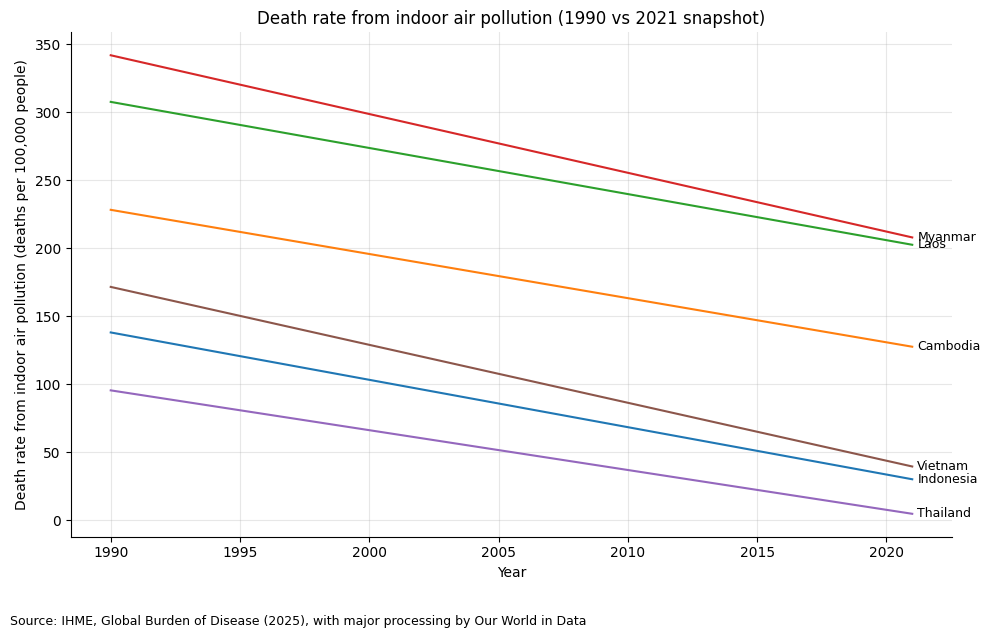

In [5]:
# Line chart: indoor air pollution death rate (1990 vs 2021 snapshot)

indicator_col = "death_rate"

fig, ax = plt.subplots()

for code, group in df_sel.groupby("Code"):
    group_sorted = group.sort_values("Year")
    country_name = group_sorted["Entity"].iloc[0]

    # Plot the line
    ax.plot(group_sorted["Year"], group_sorted[indicator_col], label=country_name)

    # Label at the last point (2021)
    last_x = group_sorted["Year"].iloc[-1]
    last_y = group_sorted[indicator_col].iloc[-1]
    ax.text(
        last_x + 0.2,
        last_y,
        country_name,
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Year")
ax.set_ylabel("Death rate from indoor air pollution (deaths per 100,000 people)")
ax.set_title("Death rate from indoor air pollution (1990 vs 2021 snapshot)")

# Remove legend (labels are on the lines)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.figtext(
    0.01,
    -0.05,
    "Source: IHME, Global Burden of Disease (2025), with major processing by Our World in Data",
    ha="left",
    fontsize=9,
)

plt.tight_layout()
plt.show()


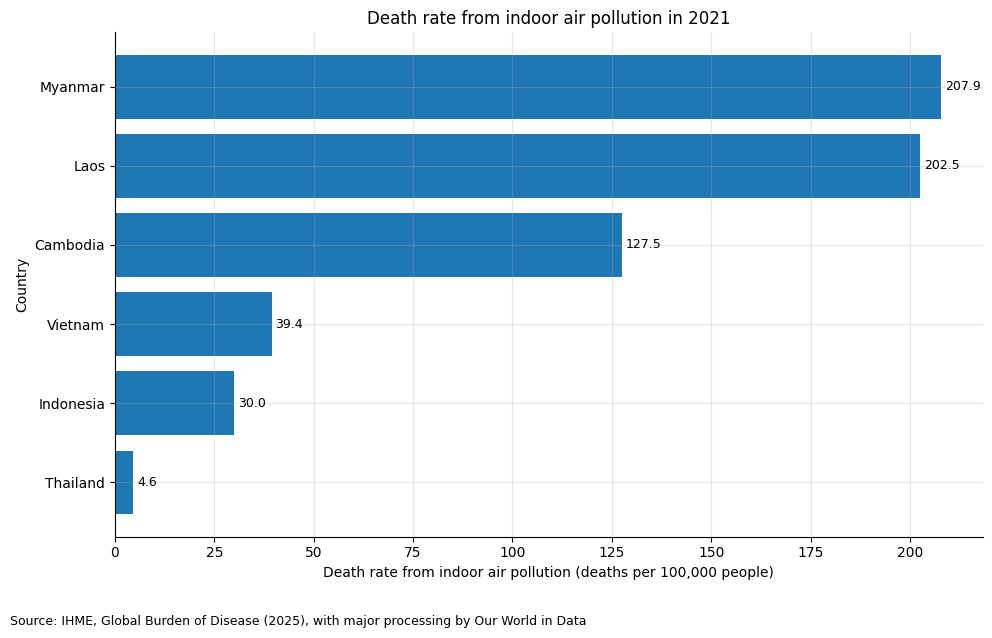

In [6]:
# Bar chart: indoor air pollution death rate in 2021

bar_2021 = df_sel[df_sel["Year"] == 2021].copy()
bar_2021 = bar_2021.sort_values(indicator_col, ascending=True)

fig, ax = plt.subplots()

bars = ax.barh(bar_2021["Entity"], bar_2021[indicator_col])

ax.set_xlabel("Death rate from indoor air pollution (deaths per 100,000 people)")
ax.set_ylabel("Country")
ax.set_title("Death rate from indoor air pollution in 2021")

# Add value labels at the end of each bar
for bar, value in zip(bars, bar_2021[indicator_col]):
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=9,
    )

plt.figtext(
    0.01,
    -0.05,
    "Source: IHME, Global Burden of Disease (2025), with major processing by Our World in Data",
    ha="left",
    fontsize=9,
)

plt.tight_layout()
plt.show()


## Licensing, attribution, and how to obtain the data

- Data and original interactive chart: Our World in Data, "Death rate from indoor air pollution" (`death-rate-by-source-from-indoor-air-pollution`).
- Original data provider: IHME, Global Burden of Disease.
- OWID and its code/visualizations are released under [Creative Commons BY](https://ourworldindata.org/grapher/death-rate-by-source-from-indoor-air-pollution#reuse); original providers retain their own licenses.

To obtain the CSV and use it in this notebook:
1. Open the [OWID chart page](https://ourworldindata.org/grapher/death-rate-by-source-from-indoor-air-pollution?tab=table&time=earliest..2021&country=THA~VNM~IDN~KHM~MMR~LAO).
2. Click **"Download"** (or the **"Data"** tab) and choose **CSV** or copy the table.
3. Save the filtered table as `data/indoor_pollution.csv` in the same folder as this notebook (i.e. `notebooks/data/indoor_pollution.csv`).
4. Re-run the notebook; it will load from this local file.
